# Temporal & Seasonal Analysis — 50 Indian Cities

This notebook studies yearly, monthly and hourly weather trends, crop-season windows (Kharif, Rabi and Zaid), and pre-monsoon signals for the same deterministic selection of 50 cities used in the statistical EDA.

Dataset: https://www.kaggle.com/datasets/mukeshdevrath007/indian-5000-cities-weather-data

In [1]:
import os
import re
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

OUTPUT_DIR = "/kaggle/working/temporal_seasonal_50_cities"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
SEASON_ORDER = ["Kharif", "Rabi", "Zaid"]
SEASON_COLORS = {"Kharif": "#2a9d8f", "Rabi": "#457b9d", "Zaid": "#e76f51"}

print("Setup complete")

Setup complete


## 1. Find the Kaggle CSV files

In [2]:
INPUT_ROOT = Path("/kaggle/input")

if not INPUT_ROOT.exists():
    raise FileNotFoundError("This notebook must be run on Kaggle.")

print("Attached datasets:")
for folder in INPUT_ROOT.iterdir():
    if folder.is_dir():
        print(" -", folder.name)

csv_files = sorted([
    str(file) for file in INPUT_ROOT.rglob("*")
    if file.is_file()
    and (file.name.lower().endswith(".csv")
         or file.name.lower().endswith(".csv.gz"))
])

if not csv_files:
    raise FileNotFoundError(
        "No CSV files found. Click Add Input and attach "
        "mukeshdevrath007/indian-5000-cities-weather-data."
    )

print(f"\nCSV files found: {len(csv_files):,}")
print("First file:", csv_files[0])

Attached datasets:
 - datasets

CSV files found: 4,686
First file: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis/weather.csv


## 2. Select the same 50 valid city files

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def get_dataset_city_name(file_path):
    path = Path(file_path)
    filename = path.name
    file_name = filename[:-7] if filename.lower().endswith(".csv.gz") else path.stem

    generic_names = {
        "weather", "weatherdata", "hourlyweather", "data", "historicalweather"
    }
    if normalize_name(file_name) in generic_names:
        return path.parent.name
    return file_name


available_df = pd.DataFrame({
    "city": [get_dataset_city_name(file) for file in csv_files],
    "file": csv_files,
})
available_df["city_key"] = available_df["city"].apply(normalize_name)

# Remove generic folder names and duplicate city files.
invalid_names = {"weather", "weatherdata", "data", "csv", "files"}
available_df = available_df[~available_df["city_key"].isin(invalid_names)]
available_df = (available_df.drop_duplicates("city_key")
                .sort_values("city").reset_index(drop=True))

# These names matched exactly in the previous 50-city notebook.
PREFERRED_CITIES = [
    "Delhi", "Mumbai", "Chennai", "Kolkata", "Hyderabad",
    "Pune", "Ahmedabad", "Jaipur", "Lucknow", "Nagpur",
    "Indore", "Bhopal", "Patna", "Rajkot", "Agra",
    "Prayagraj", "Ranchi", "Raipur", "Cuttack", "Guwahati",
    "Imphal", "Aizawl", "Agartala", "Kohima", "Itanagar",
    "Dehradun", "Chandigarh", "Jammu", "Leh", "Amritsar",
    "Ludhiana", "Jodhpur", "Kota", "Kochi", "Coimbatore"
]
preferred_keys = {normalize_name(city) for city in PREFERRED_CITIES}

selected_files = available_df[available_df["city_key"].isin(preferred_keys)].copy()
remaining_files = available_df[~available_df["city_key"].isin(selected_files["city_key"])].reset_index(drop=True)

needed = 50 - len(selected_files)
if needed > 0:
    indices = np.linspace(0, len(remaining_files) - 1, needed, dtype=int)
    selected_files = pd.concat(
        [selected_files, remaining_files.iloc[indices]], ignore_index=True
    )

selected_files = selected_files.head(50)[["city", "file"]]

if len(selected_files) != 50 or selected_files["city"].nunique() != 50:
    raise ValueError("Could not select 50 unique valid city files.")

print("Selected cities:", len(selected_files))
display(selected_files)

selected_files.to_csv(
    os.path.join(OUTPUT_DIR, "selected_50_cities.csv"), index=False
)

Selected cities: 50


,city,file
0,Agartala,/kaggle/input/datasets/mukeshdevrath007/indian...
1,Agra,/kaggle/input/datasets/mukeshdevrath007/indian...
2,Ahmedabad,/kaggle/input/datasets/mukeshdevrath007/indian...
3,Aizawl,/kaggle/input/datasets/mukeshdevrath007/indian...
4,Amritsar,/kaggle/input/datasets/mukeshdevrath007/indian...
5,Bhopal,/kaggle/input/datasets/mukeshdevrath007/indian...
6,Chandigarh,/kaggle/input/datasets/mukeshdevrath007/indian...
7,Chennai,/kaggle/input/datasets/mukeshdevrath007/indian...
8,Coimbatore,/kaggle/input/datasets/mukeshdevrath007/indian...
9,Cuttack,/kaggle/input/datasets/mukeshdevrath007/indian...


## 3. Match weather columns and create compact summaries

In [10]:
COLUMN_ALIASES = {
    "time": ["time", "datetime", "date"],
    "temperature_2m": ["temperature2m", "temp2m", "temperature"],
    "relative_humidity_2m": ["relativehumidity2m", "humidity2m", "relativehumidity"],
    "dew_point_2m": ["dewpoint2m", "dewpoint"],
    "precipitation": ["precipitation", "precip"],
    "rain": ["rain"],
    "wind_speed_10m": ["windspeed10m", "wind10m"],
    "wind_speed_100m": ["windspeed100m", "wind100m"],
    "cloud_cover": ["cloudcover", "cloudiness"],
    "pressure_msl": ["pressuremsl", "sealevelpressure"],
}


def match_columns(columns):
    normalized = {column: normalize_name(column) for column in columns}
    matched = {}

    for standard, aliases in COLUMN_ALIASES.items():
        aliases = [normalize_name(alias) for alias in aliases]
        exact = [column for column, name in normalized.items() if name in aliases]
        prefix = [column for column, name in normalized.items()
                  if any(name.startswith(alias) for alias in aliases)]
        if exact or prefix:
            matched[standard] = (exact or prefix)[0]

    return matched


def summarize_city(file, city):
    header = pd.read_csv(file, nrows=0).columns.tolist()
    matched = match_columns(header)

    if "time" not in matched:
        raise ValueError("date/time column not found")
    if "temperature_2m" not in matched:
        raise ValueError("temperature column not found")

    usecols = list(dict.fromkeys(matched.values()))
    raw = pd.read_csv(file, usecols=usecols, low_memory=False)
    raw = raw.rename(columns={original: standard for standard, original in matched.items()})

    raw["datetime"] = pd.to_datetime(raw.pop("time"), errors="coerce", utc=True)
    raw["datetime"] = raw["datetime"].dt.tz_localize(None)
    raw = raw.dropna(subset=["datetime"])

    for column in raw.columns.difference(["datetime"]):
        raw[column] = pd.to_numeric(raw[column], errors="coerce", downcast="float")

    raw["date"] = raw["datetime"].dt.floor("D")
    raw["month"] = raw["datetime"].dt.month.astype("int8")
    raw["hour"] = raw["datetime"].dt.hour.astype("int8")

    # Daily data for yearly, monthly, crop-season and pre-monsoon analyses.
    grouped = raw.groupby("date", sort=False)
    daily = pd.DataFrame(index=grouped.size().index)

    def add_daily(source, outputs):
        if source in raw.columns:
            for output, operation in outputs.items():
                daily[output] = grouped[source].agg(operation)

    add_daily("temperature_2m", {"temp_mean": "mean", "temp_max": "max", "temp_min": "min"})
    add_daily("relative_humidity_2m", {"humidity_mean": "mean"})
    add_daily("dew_point_2m", {"dew_mean": "mean"})
    add_daily("precipitation", {"precip_total": "sum"})
    if "precip_total" not in daily.columns:
        add_daily("rain", {"precip_total": "sum"})
    add_daily("wind_speed_10m", {"wind_mean_10m": "mean"})
    add_daily("wind_speed_100m", {"wind_mean_100m": "mean"})
    add_daily("cloud_cover", {"cloud_mean": "mean"})
    add_daily("pressure_msl", {"pressure_mean": "mean"})

    daily = daily.reset_index()
    daily.insert(1, "city", city)

    # Compact hourly profile: at most 12 x 24 rows per city.
    hour_keys = ["month", "hour"]
    hour_agg = {}
    for source, output in [
        ("temperature_2m", "temp_mean"),
        ("relative_humidity_2m", "humidity_mean"),
        ("precipitation", "precip_mean"),
        ("rain", "rain_mean"),
        ("wind_speed_100m", "wind_mean_100m"),
        ("wind_speed_10m", "wind_mean_10m"),
        ("cloud_cover", "cloud_mean"),
    ]:
        if source in raw.columns:
            hour_agg[output] = (source, "mean")

    hourly = raw.groupby(hour_keys).agg(**hour_agg).reset_index()
    if "precip_mean" not in hourly.columns and "rain_mean" in hourly.columns:
        hourly = hourly.rename(columns={"rain_mean": "precip_mean"})
    hourly.insert(0, "city", city)

    del raw
    gc.collect()
    return daily, hourly, matched

Processed 10/50 city files
Processed 20/50 city files
Processed 30/50 city files
Processed 40/50 city files
Processed 50/50 city files


,city,status,daily_rows,matched_columns,error
0,Agartala,loaded,5164,10,
1,Agra,loaded,5164,10,
2,Ahmedabad,loaded,5164,10,
3,Aizawl,loaded,5164,10,
4,Amritsar,loaded,5164,10,
5,Bhopal,loaded,5164,10,
6,Chandigarh,loaded,5164,10,
7,Chennai,loaded,5164,10,
8,Coimbatore,loaded,5164,10,
9,Cuttack,loaded,5164,10,


Successfully loaded: 49
Skipped files      : 1

Processing completed
Daily shape : (253036, 14)
Hourly shape: (14112, 10)
Cities loaded: 49
Date range: 2010-01-01 to 2024-02-20


In [9]:
daily_frames = []
hourly_frames = []
load_log = []

for position, row in selected_files.reset_index(drop=True).iterrows():
    try:
        city_daily, city_hourly, 
        matched = summarize_city(row["file"], row["city"])
        daily_frames.append(city_daily)
        hourly_frames.append(city_hourly)
        load_log.append({
            "city": row["city"], "status": "loaded",
            "daily_rows": len(city_daily), "matched_columns": len(matched), "error": ""
        })
    except Exception as error:
        load_log.append({
            "city": row["city"], "status": "skipped", "daily_rows": 0,
            "matched_columns": 0, "error": str(error)[:150]
        })

    if (position + 1) % 10 == 0:
        print(f"Processed {position + 1}/50 city files")

load_log = pd.DataFrame(load_log)
display(load_log)

if not daily_frames:
    raise RuntimeError("No city files were loaded. Review the load log.")

daily_df = pd.concat(daily_frames, ignore_index=True)
hourly_df = pd.concat(hourly_frames, ignore_index=True)

daily_df["year"] = daily_df["date"].dt.year
daily_df["month"] = daily_df["date"].dt.month

print("Daily shape :", daily_df.shape)
print("Hourly shape:", hourly_df.shape)
print("Cities loaded:", daily_df["city"].nunique())
print("Date range:", daily_df["date"].min().date(), "to", daily_df["date"].max().date())

Processed 10/50 city files
Processed 20/50 city files
Processed 30/50 city files
Processed 40/50 city files
Processed 50/50 city files


,city,status,daily_rows,matched_columns,error
0,Agartala,skipped,0,0,name 'city_daily' is not defined
1,Agra,skipped,0,0,name 'city_daily' is not defined
2,Ahmedabad,skipped,0,0,name 'city_daily' is not defined
3,Aizawl,skipped,0,0,name 'city_daily' is not defined
4,Amritsar,skipped,0,0,name 'city_daily' is not defined
5,Bhopal,skipped,0,0,name 'city_daily' is not defined
6,Chandigarh,skipped,0,0,name 'city_daily' is not defined
7,Chennai,skipped,0,0,name 'city_daily' is not defined
8,Coimbatore,skipped,0,0,name 'city_daily' is not defined
9,Cuttack,skipped,0,0,name 'city_daily' is not defined


RuntimeError: No city files were loaded. Review the load log.

## 4. Add crop-season labels

In [11]:
def crop_season(month):
    if month in [6, 7, 8, 9]:
        return "Kharif"
    if month in [10, 11, 12, 1, 2]:
        return "Rabi"
    return "Zaid"


daily_df["crop_season"] = daily_df["month"].apply(crop_season)
hourly_df["crop_season"] = hourly_df["month"].apply(crop_season)

print("Crop-season distribution:")
display(daily_df["crop_season"].value_counts().reindex(SEASON_ORDER).to_frame("daily_rows"))

Crop-season distribution:


,daily_rows
crop_season,
Kharif,83692
Rabi,106232
Zaid,63112


## 5. Yearly weather trends

,year,observed_days,temperature,annual_precipitation,humidity,wind_100m,cloud_cover
0,2010,365.00,24.70,1330.66,67.20,13.58,34.05
1,2011,365.00,23.97,1294.28,67.18,13.54,32.17
2,2012,366.00,24.09,1100.22,64.34,14.18,31.88
3,2013,365.00,23.83,1297.59,68.01,14.05,34.42
4,2014,365.00,24.07,1119.69,66.53,13.75,32.70
5,2015,365.00,24.13,1246.39,68.39,13.42,33.71
6,2016,366.00,24.68,1201.76,66.50,13.80,32.77
7,2017,365.00,24.50,1329.08,66.25,14.77,30.98
8,2018,365.00,24.28,1221.46,65.72,14.84,29.22
9,2019,365.00,24.28,1389.48,67.97,14.83,31.49


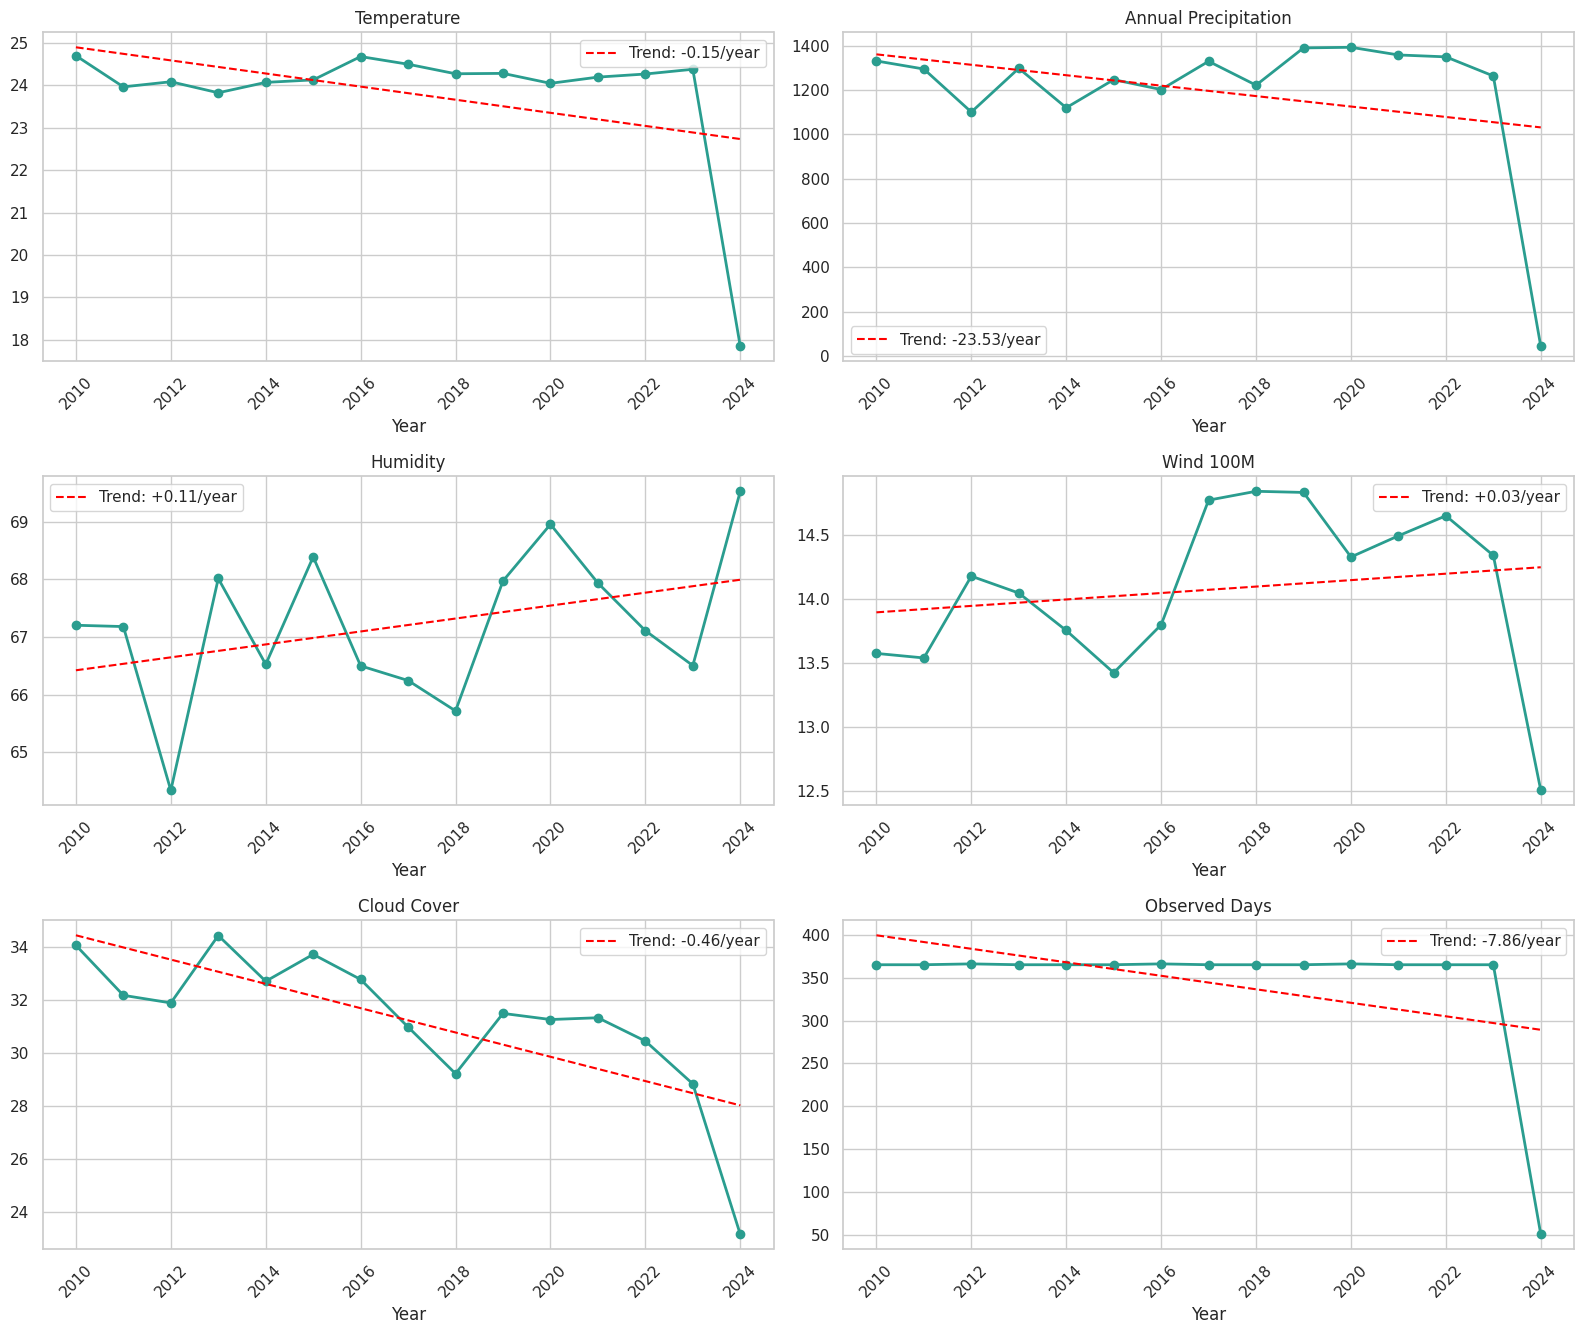

In [12]:
# First calculate each city-year, then average across cities.
# This prevents cities with more records from dominating the national trend.
year_agg = {"observed_days": ("date", "size")}
if "temp_mean" in daily_df:
    year_agg["temperature"] = ("temp_mean", "mean")
if "precip_total" in daily_df:
    year_agg["annual_precipitation"] = ("precip_total", "sum")
if "humidity_mean" in daily_df:
    year_agg["humidity"] = ("humidity_mean", "mean")
if "wind_mean_100m" in daily_df:
    year_agg["wind_100m"] = ("wind_mean_100m", "mean")
if "cloud_mean" in daily_df:
    year_agg["cloud_cover"] = ("cloud_mean", "mean")

city_year = daily_df.groupby(["city", "year"]).agg(**year_agg).reset_index()
yearly = city_year.groupby("year").mean(numeric_only=True).reset_index()
display(yearly)

trend_cols = [c for c in ["temperature", "annual_precipitation", "humidity",
                           "wind_100m", "cloud_cover", "observed_days"] if c in yearly]

fig, axes = plt.subplots(int(np.ceil(len(trend_cols) / 2)), 2,
                         figsize=(16, 4.5 * int(np.ceil(len(trend_cols) / 2))), squeeze=False)

for ax, column in zip(axes.flat, trend_cols):
    ax.plot(yearly["year"], yearly[column], marker="o", linewidth=2, color="#2a9d8f")
    valid = yearly[["year", column]].dropna()
    if len(valid) >= 2:
        slope, intercept = np.polyfit(valid["year"], valid[column], 1)
        ax.plot(valid["year"], slope * valid["year"] + intercept,
                linestyle="--", color="red", label=f"Trend: {slope:+.2f}/year")
        ax.legend()
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("Year")
    ax.tick_params(axis="x", rotation=45)

for ax in axes.flat[len(trend_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "yearly_trends.png"), dpi=140, bbox_inches="tight")
plt.show()

## 6. Monthly seasonal patterns

,month,temperature,maximum_temperature,minimum_temperature,daily_precipitation,humidity,wind_100m,cloud_cover,dew_point
0,1,17.03,23.10,11.54,0.69,68.38,12.48,20.46,10.29
1,2,19.90,26.38,13.79,0.77,60.65,13.36,16.59,10.81
2,3,24.06,30.73,17.65,0.99,53.84,13.86,15.77,12.33
3,4,27.73,34.29,21.45,1.61,50.51,14.57,19.34,14.09
4,5,29.46,35.40,23.93,2.72,54.67,15.97,24.90,17.15
5,6,28.90,33.51,24.88,5.75,66.89,17.41,44.07,20.91
6,7,27.00,30.55,24.22,9.26,79.74,17.56,62.14,22.83
7,8,26.50,30.00,23.82,8.27,81.68,16.28,60.28,22.82
8,9,26.12,30.05,22.96,6.23,80.06,13.90,47.02,22.02
9,10,24.64,29.67,20.16,3.02,71.45,11.16,27.75,18.33


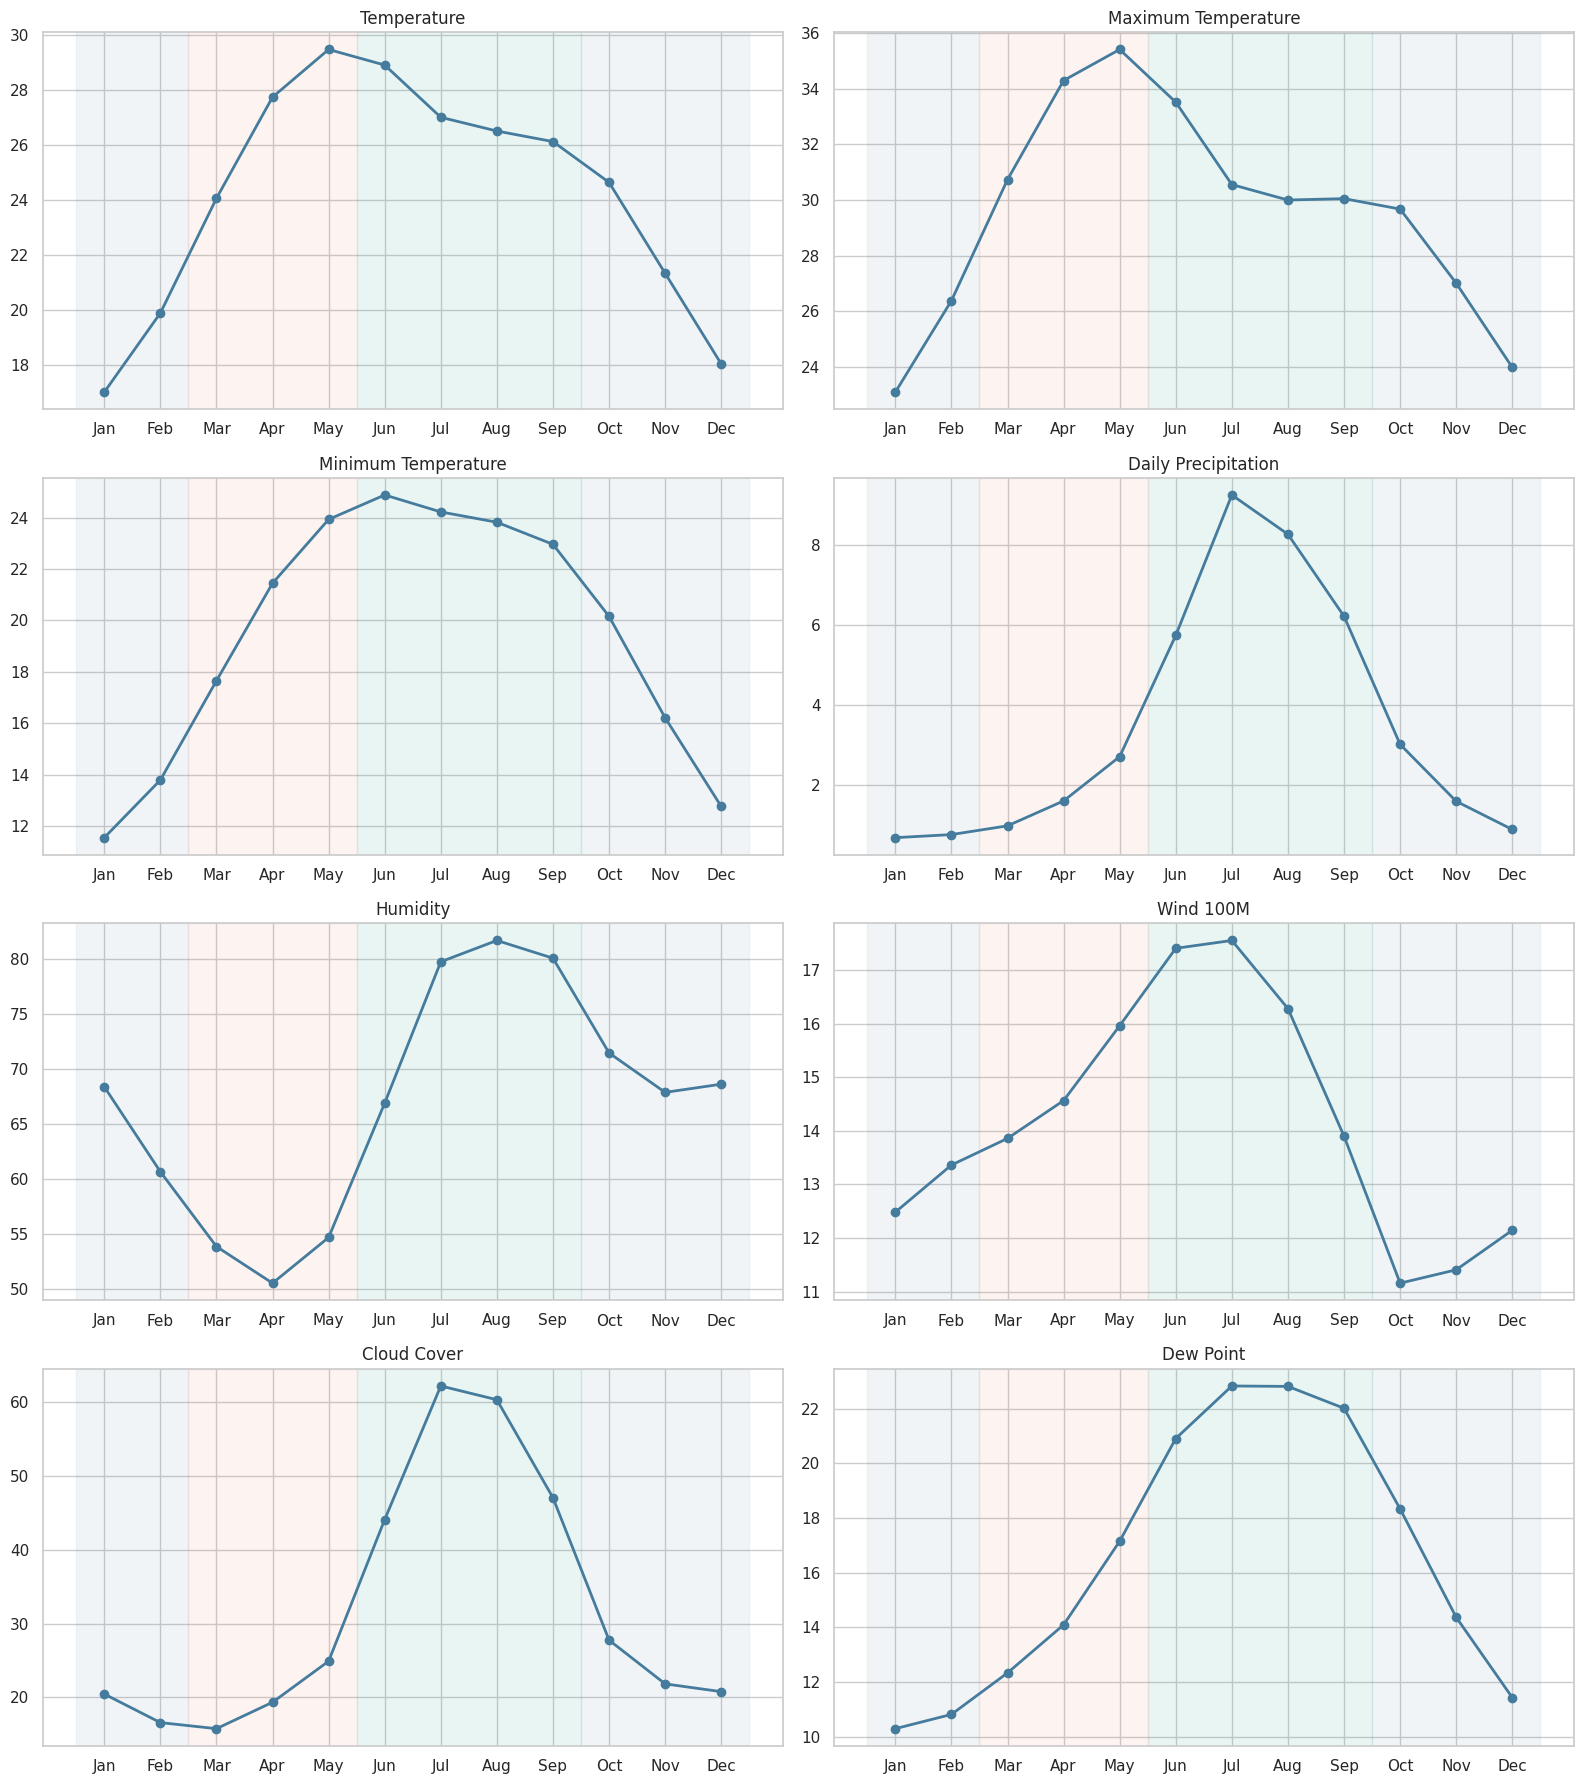

Hottest month: May
Wettest month: Jul


In [13]:
month_agg = {}
for source, output, operation in [
    ("temp_mean", "temperature", "mean"),
    ("temp_max", "maximum_temperature", "mean"),
    ("temp_min", "minimum_temperature", "mean"),
    ("precip_total", "daily_precipitation", "mean"),
    ("humidity_mean", "humidity", "mean"),
    ("wind_mean_100m", "wind_100m", "mean"),
    ("cloud_mean", "cloud_cover", "mean"),
    ("dew_mean", "dew_point", "mean"),
]:
    if source in daily_df:
        month_agg[output] = (source, operation)

monthly = daily_df.groupby("month").agg(**month_agg).reset_index()
display(monthly)

monthly_plot_cols = [c for c in monthly.columns if c != "month"]
fig, axes = plt.subplots(int(np.ceil(len(monthly_plot_cols) / 2)), 2,
                         figsize=(16, 4.5 * int(np.ceil(len(monthly_plot_cols) / 2))), squeeze=False)

for ax, column in zip(axes.flat, monthly_plot_cols):
    ax.plot(monthly["month"], monthly[column], marker="o", linewidth=2, color="#457b9d")
    ax.set_xticks(range(1, 13), MONTH_NAMES)
    ax.set_title(column.replace("_", " ").title())
    ax.axvspan(5.5, 9.5, color=SEASON_COLORS["Kharif"], alpha=0.10)
    ax.axvspan(9.5, 12.5, color=SEASON_COLORS["Rabi"], alpha=0.08)
    ax.axvspan(0.5, 2.5, color=SEASON_COLORS["Rabi"], alpha=0.08)
    ax.axvspan(2.5, 5.5, color=SEASON_COLORS["Zaid"], alpha=0.08)

for ax in axes.flat[len(monthly_plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "monthly_patterns.png"), dpi=140, bbox_inches="tight")
plt.show()

if "temperature" in monthly:
    hottest = int(monthly.loc[monthly["temperature"].idxmax(), "month"])
    print("Hottest month:", MONTH_NAMES[hottest - 1])
if "daily_precipitation" in monthly:
    wettest = int(monthly.loc[monthly["daily_precipitation"].idxmax(), "month"])
    print("Wettest month:", MONTH_NAMES[wettest - 1])

## 7. Hourly weather trends

,hour,temp_mean,humidity_mean,precip_mean,wind_mean_100m,wind_mean_10m,cloud_mean
0,0,20.04,82.11,0.13,14.18,7.70,34.86
1,1,20.27,81.77,0.13,13.91,7.84,35.03
2,2,21.45,77.97,0.12,13.29,8.23,34.12
3,3,23.44,70.27,0.11,12.48,8.55,33.08
4,4,25.36,62.92,0.12,12.16,8.94,32.65
5,5,26.91,57.26,0.14,12.29,9.33,32.76
6,6,28.05,53.19,0.16,12.56,9.64,33.25
7,7,28.74,50.89,0.19,12.89,9.91,33.79
8,8,29.12,49.54,0.22,13.29,10.19,34.10
9,9,29.14,49.33,0.24,13.71,10.42,33.94


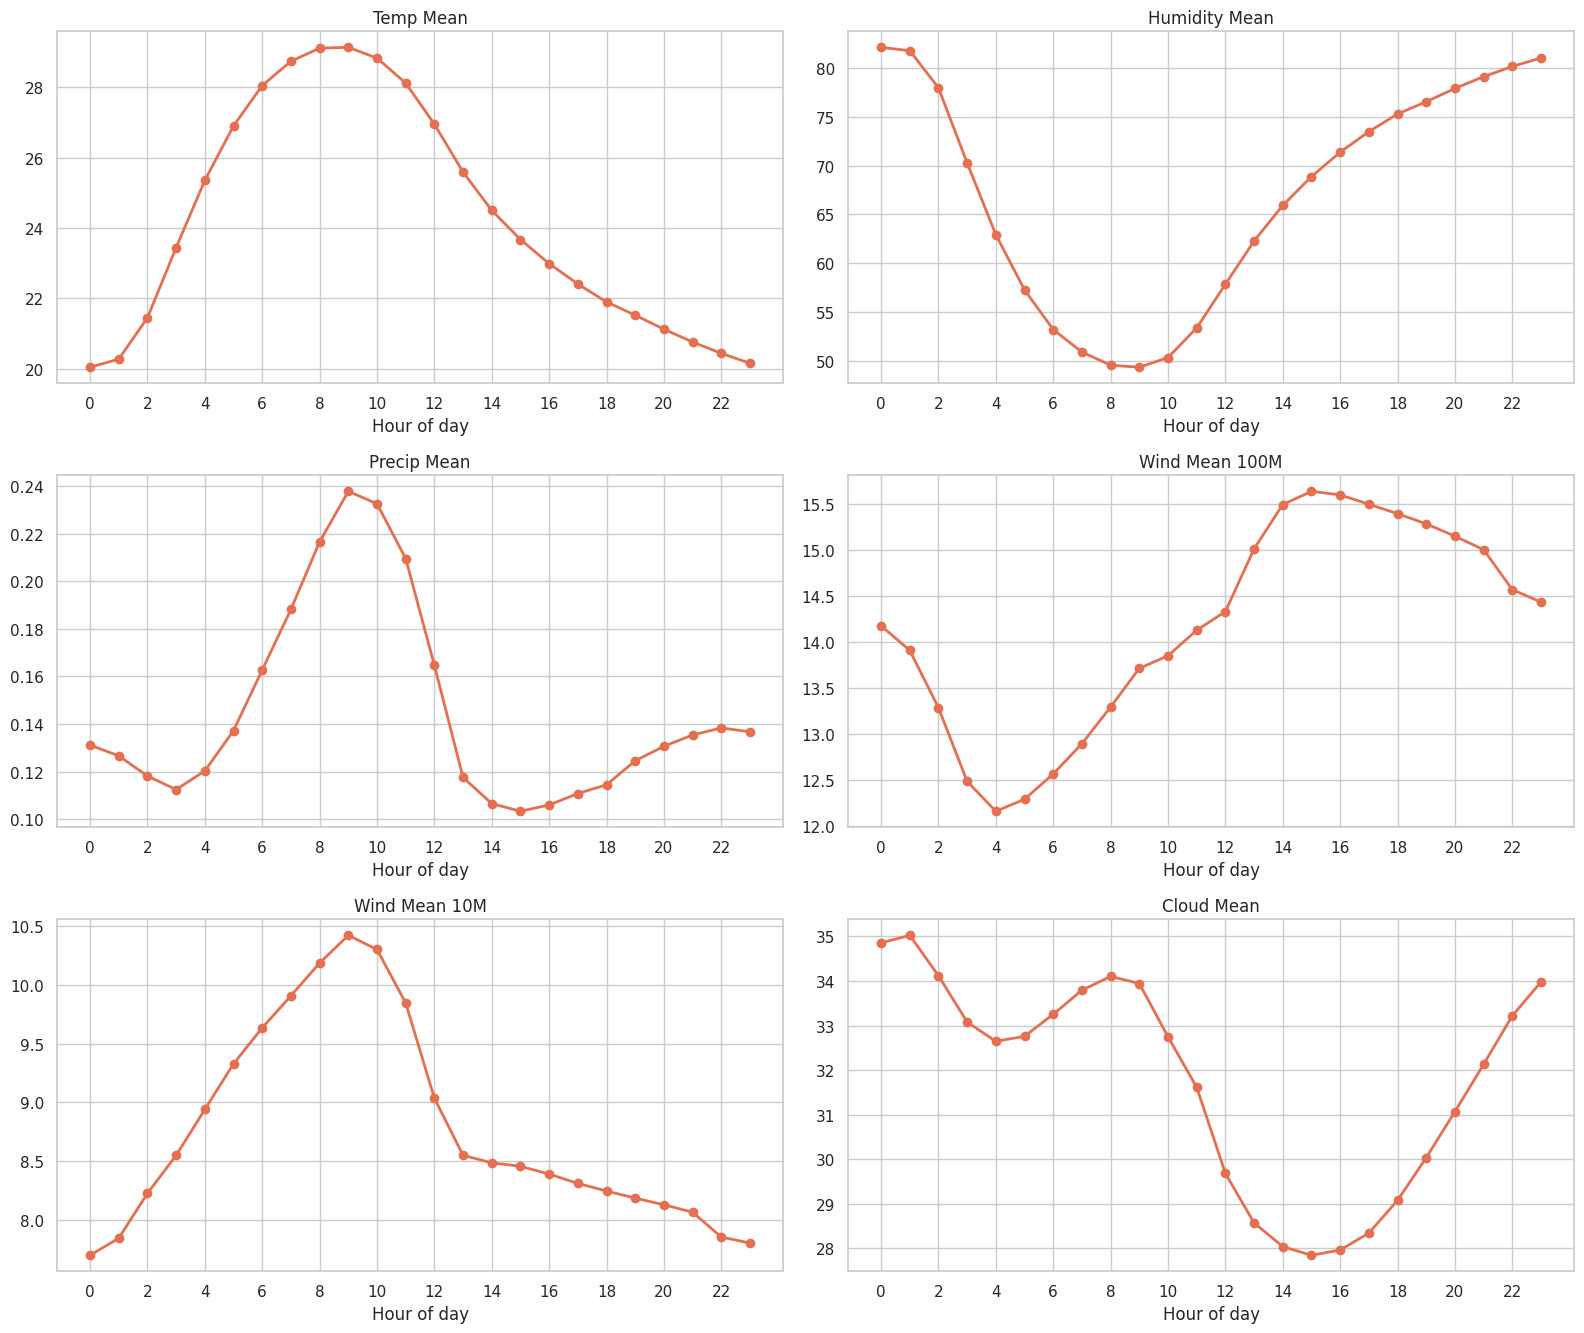

In [14]:
hour_columns = [c for c in ["temp_mean", "humidity_mean", "precip_mean",
                             "wind_mean_100m", "wind_mean_10m", "cloud_mean"]
                if c in hourly_df]
hourly_profile = hourly_df.groupby("hour")[hour_columns].mean().reset_index()
display(hourly_profile)

fig, axes = plt.subplots(int(np.ceil(len(hour_columns) / 2)), 2,
                         figsize=(16, 4.5 * int(np.ceil(len(hour_columns) / 2))), squeeze=False)

for ax, column in zip(axes.flat, hour_columns):
    ax.plot(hourly_profile["hour"], hourly_profile[column],
            marker="o", color="#e76f51", linewidth=2)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlabel("Hour of day")
    ax.set_title(column.replace("_", " ").title())

for ax in axes.flat[len(hour_columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hourly_trends.png"), dpi=140, bbox_inches="tight")
plt.show()

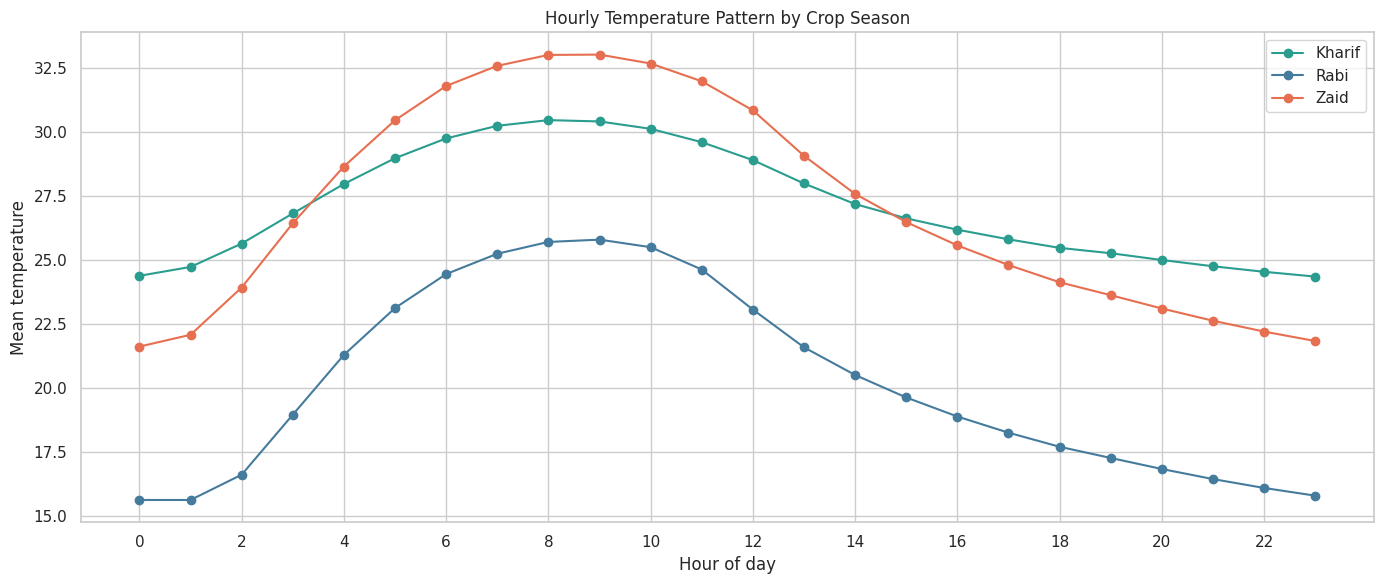

In [15]:
# Hourly temperature pattern within each crop season.
if "temp_mean" in hourly_df:
    season_hour = (hourly_df.groupby(["crop_season", "hour"])["temp_mean"]
                   .mean().reset_index())

    plt.figure(figsize=(14, 6))
    for season in SEASON_ORDER:
        part = season_hour[season_hour["crop_season"] == season]
        plt.plot(part["hour"], part["temp_mean"], marker="o",
                 color=SEASON_COLORS[season], label=season)
    plt.xticks(range(0, 24, 2))
    plt.xlabel("Hour of day")
    plt.ylabel("Mean temperature")
    plt.title("Hourly Temperature Pattern by Crop Season")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "hourly_temperature_by_season.png"),
                dpi=140, bbox_inches="tight")
    plt.show()

## 8. Crop-season window analysis

,year,observations,temperature,total_precipitation,humidity,wind_100m,cloud_cover
crop_season,,,,,,,
Kharif,2016.50,122.00,27.12,902.61,77.15,16.30,53.51
Rabi,2017.00,144.53,20.04,201.01,67.55,12.13,21.58
Zaid,2016.50,92.00,27.08,163.19,53.03,14.80,20.01


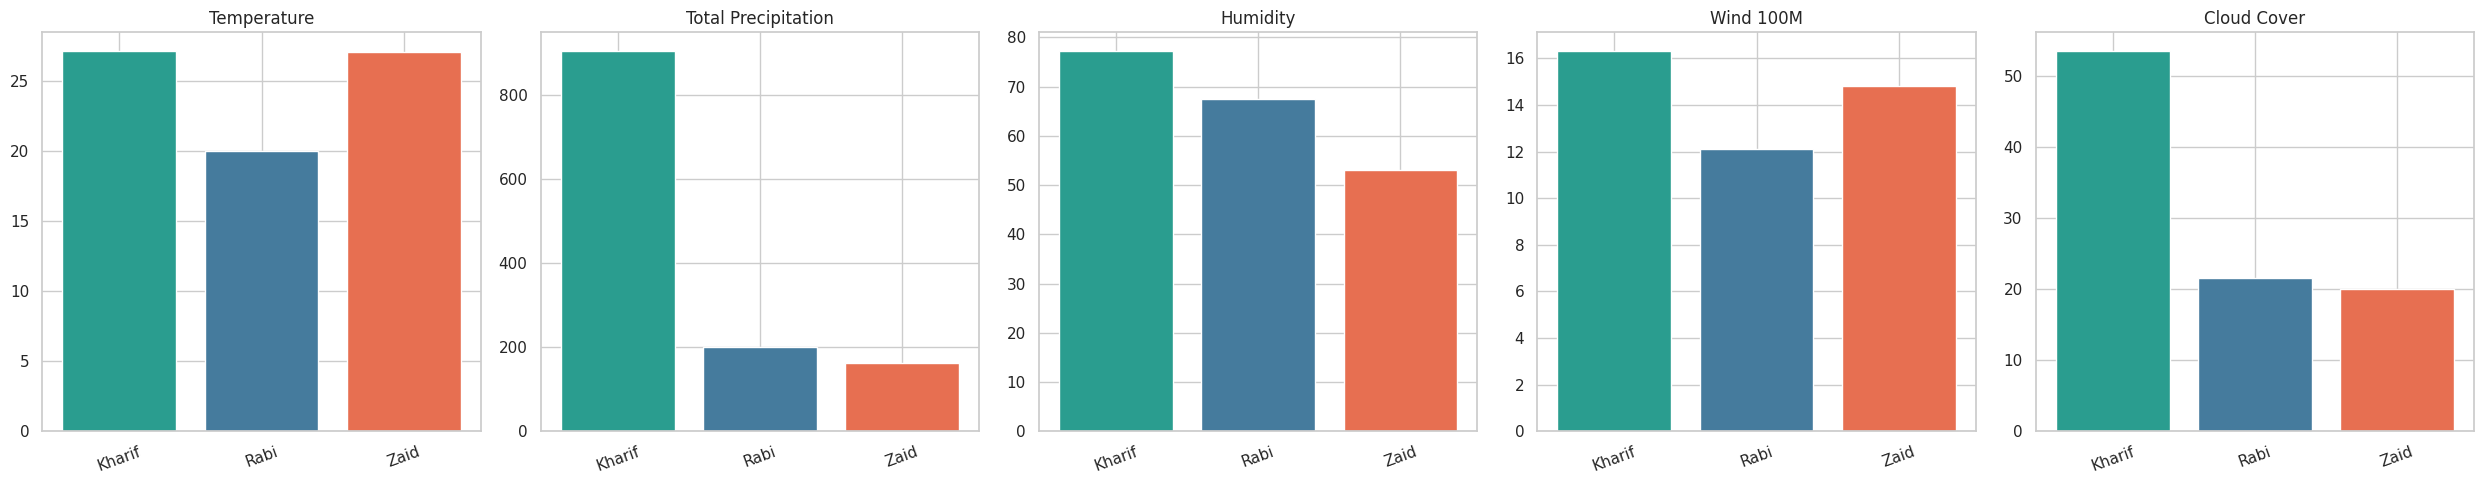

In [16]:
season_agg = {"observations": ("date", "size")}
for source, output, operation in [
    ("temp_mean", "temperature", "mean"),
    ("precip_total", "total_precipitation", "sum"),
    ("humidity_mean", "humidity", "mean"),
    ("wind_mean_100m", "wind_100m", "mean"),
    ("cloud_mean", "cloud_cover", "mean"),
]:
    if source in daily_df:
        season_agg[output] = (source, operation)

city_season_year = (daily_df.groupby(["city", "year", "crop_season"])
                    .agg(**season_agg).reset_index())
season_summary = (city_season_year.groupby("crop_season")
                  .mean(numeric_only=True).reindex(SEASON_ORDER))
display(season_summary)

plot_season_cols = [c for c in ["temperature", "total_precipitation",
                                 "humidity", "wind_100m", "cloud_cover"]
                    if c in season_summary]

fig, axes = plt.subplots(1, len(plot_season_cols),
                         figsize=(5 * len(plot_season_cols), 5), squeeze=False)
for ax, column in zip(axes.flat, plot_season_cols):
    values = season_summary[column]
    ax.bar(values.index, values.values,
           color=[SEASON_COLORS[s] for s in values.index])
    ax.set_title(column.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "crop_season_comparison.png"),
            dpi=140, bbox_inches="tight")
plt.show()

## 9. Pre-monsoon signal analysis

March–May is treated as the pre-monsoon window. Temperature, rainfall, humidity, cloud cover and wind anomalies are calculated for each city and year. Positive anomaly means the value was above that city's long-term pre-monsoon average.

,year,pre_temp,pre_rain,pre_humidity,pre_cloud,pre_wind,pre_temp_anomaly,pre_rain_anomaly,pre_humidity_anomaly,pre_cloud_anomaly,pre_wind_anomaly
0,2010,28.73,157.71,49.38,19.73,15.34,1.65,-5.48,-3.65,-0.29,0.54
1,2011,26.76,166.44,53.82,18.95,13.85,-0.32,3.25,0.79,-1.06,-0.95
2,2012,27.10,109.82,49.11,18.37,14.74,0.02,-53.37,-3.92,-1.64,-0.06
3,2013,27.13,154.01,52.06,20.69,14.67,0.05,-9.18,-0.98,0.67,-0.13
4,2014,26.53,144.12,53.23,20.16,13.88,-0.55,-19.07,0.19,0.15,-0.92
5,2015,26.22,236.36,59.11,23.76,13.55,-0.85,73.17,6.08,3.75,-1.25
6,2016,27.91,171.13,53.11,21.65,14.76,0.83,7.94,0.07,1.63,-0.04
7,2017,27.26,171.88,51.86,19.07,16.05,0.18,8.68,-1.17,-0.94,1.25
8,2018,27.11,171.99,52.91,19.22,15.23,0.03,8.80,-0.12,-0.79,0.43
9,2019,27.07,110.81,52.20,17.09,15.48,-0.01,-52.38,-0.84,-2.92,0.68


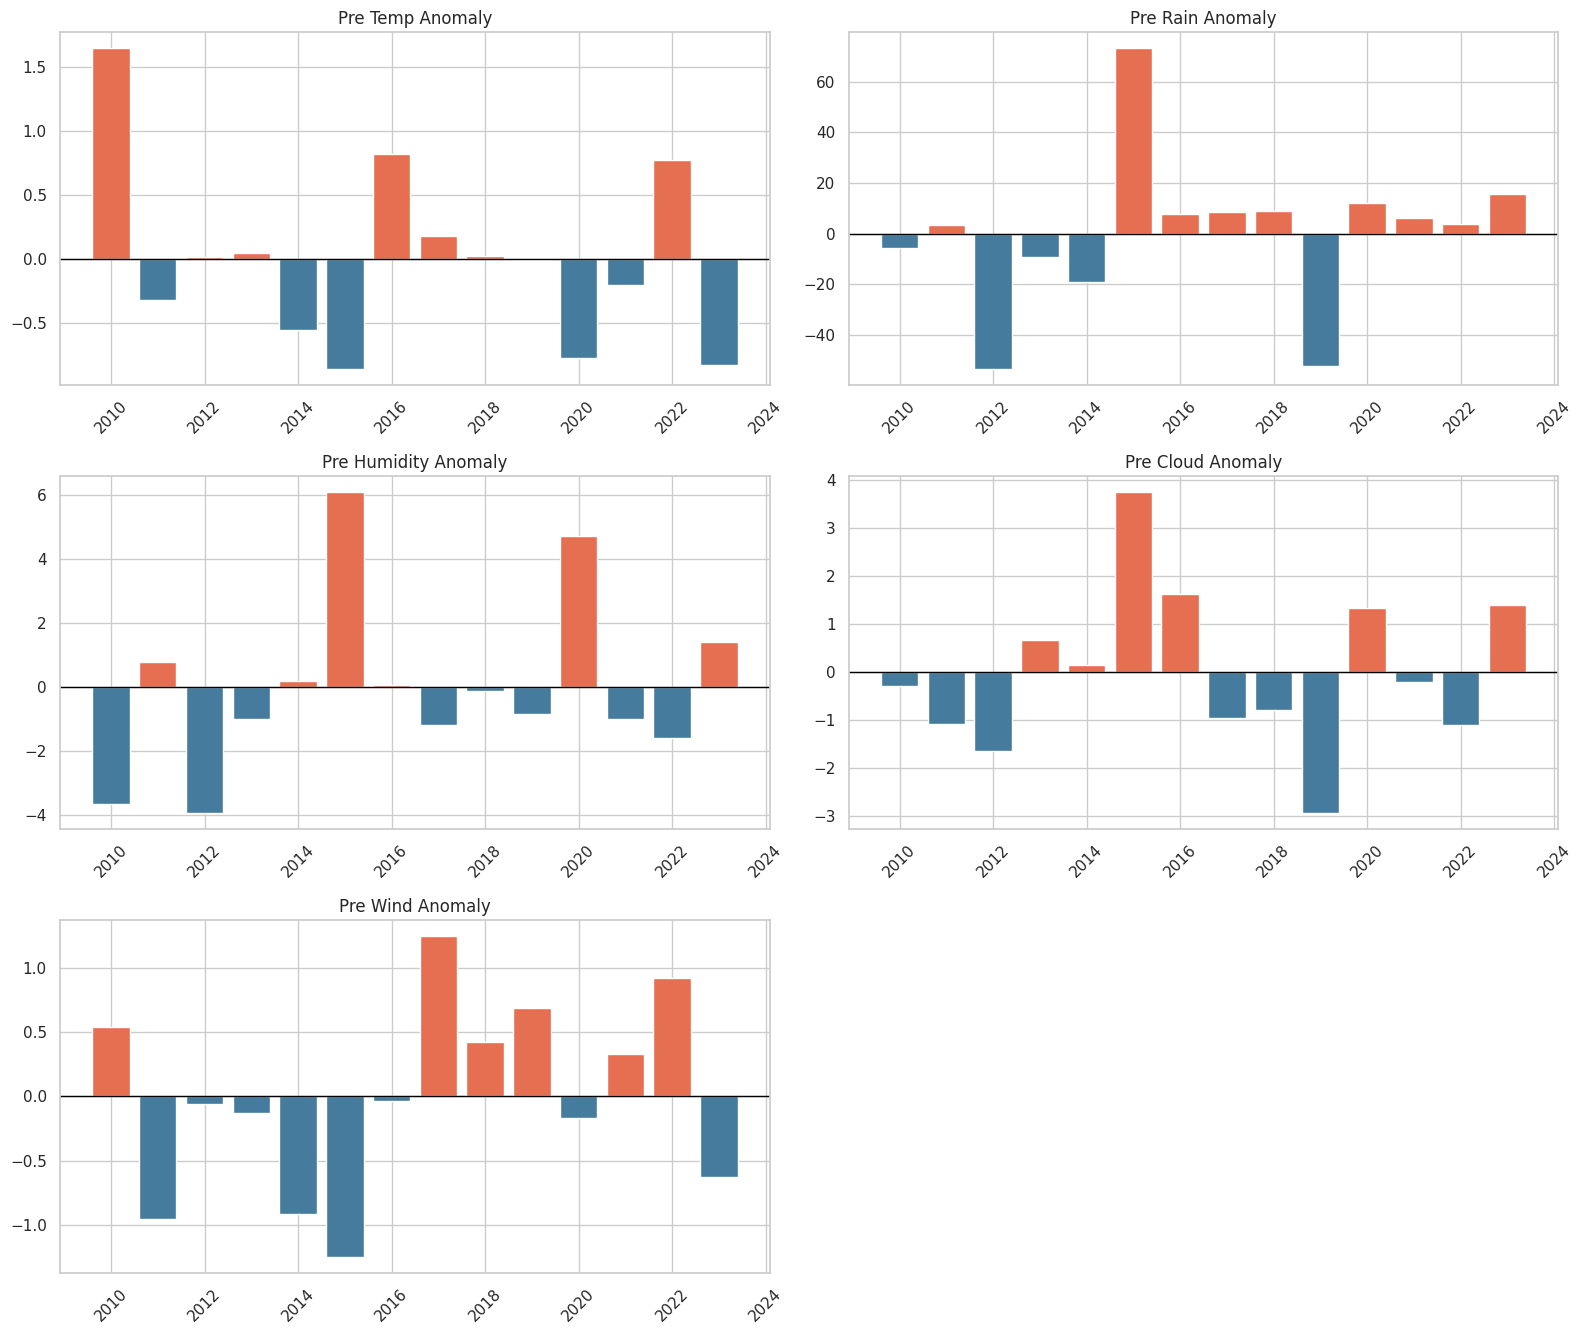

In [17]:
pre_monsoon = daily_df[daily_df["month"].isin([3, 4, 5])].copy()

pre_agg = {}
for source, output, operation in [
    ("temp_mean", "pre_temp", "mean"),
    ("precip_total", "pre_rain", "sum"),
    ("humidity_mean", "pre_humidity", "mean"),
    ("cloud_mean", "pre_cloud", "mean"),
    ("wind_mean_100m", "pre_wind", "mean"),
]:
    if source in pre_monsoon:
        pre_agg[output] = (source, operation)

pre_city_year = (pre_monsoon.groupby(["city", "year"])
                 .agg(**pre_agg).reset_index())

signal_columns = [c for c in pre_city_year.columns if c.startswith("pre_")]
for column in signal_columns:
    baseline = pre_city_year.groupby("city")[column].transform("mean")
    pre_city_year[column + "_anomaly"] = pre_city_year[column] - baseline

pre_yearly = pre_city_year.groupby("year").mean(numeric_only=True).reset_index()
display(pre_yearly)

anomaly_columns = [c for c in pre_yearly.columns if c.endswith("_anomaly")]
fig, axes = plt.subplots(int(np.ceil(len(anomaly_columns) / 2)), 2,
                         figsize=(16, 4.5 * int(np.ceil(len(anomaly_columns) / 2))), squeeze=False)

for ax, column in zip(axes.flat, anomaly_columns):
    colors = np.where(pre_yearly[column] >= 0, "#e76f51", "#457b9d")
    ax.bar(pre_yearly["year"], pre_yearly[column], color=colors)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(column.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=45)

for ax in axes.flat[len(anomaly_columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pre_monsoon_anomalies.png"),
            dpi=140, bbox_inches="tight")
plt.show()

## 10. Monsoon-onset signal proxy

For EDA, the onset proxy is the first date from 15 May to 31 July when the 7-day rolling rainfall total reaches at least 25 mm. If humidity is available, its 7-day mean must also reach 60%. This is an analytical proxy, not an official IMD monsoon-onset declaration.

,city,year,onset_proxy,onset_day_of_year
0,Abbigeri,2010,2010-06-09,160.00
1,Abbigeri,2011,2011-06-02,153.00
2,Abbigeri,2012,2012-06-18,170.00
3,Abbigeri,2013,2013-06-01,152.00
4,Abbigeri,2014,2014-06-05,156.00
5,Abbigeri,2015,2015-06-13,164.00
6,Abbigeri,2016,2016-06-03,155.00
7,Abbigeri,2017,2017-06-07,158.00
8,Abbigeri,2018,2018-05-29,149.00
9,Abbigeri,2019,2019-06-22,173.00


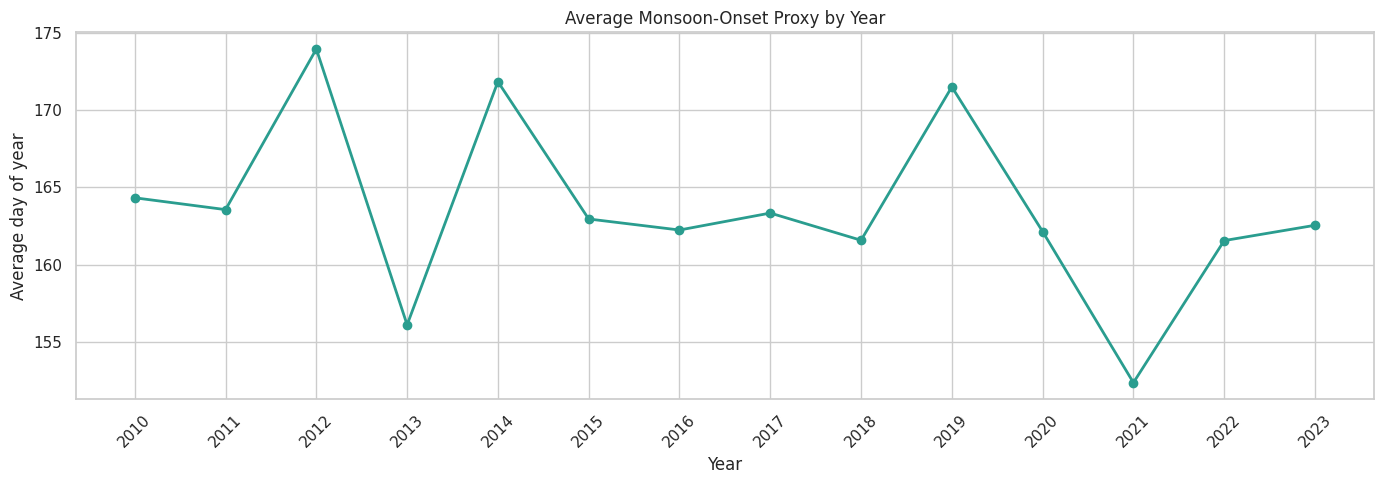

In [18]:
onset_rows = []

if "precip_total" in daily_df:
    for (city, year), group in daily_df.groupby(["city", "year"]):
        window = group[
            (group["date"] >= pd.Timestamp(year=int(year), month=5, day=15)) &
            (group["date"] <= pd.Timestamp(year=int(year), month=7, day=31))
        ].sort_values("date").copy()

        if window.empty:
            continue

        window["rain_7d"] = window["precip_total"].rolling(7, min_periods=7).sum()
        signal = window["rain_7d"] >= 25

        if "humidity_mean" in window:
            window["humidity_7d"] = window["humidity_mean"].rolling(7, min_periods=7).mean()
            signal &= window["humidity_7d"] >= 60

        candidates = window.loc[signal, "date"]
        onset_date = candidates.iloc[0] if not candidates.empty else pd.NaT
        onset_rows.append({"city": city, "year": int(year), "onset_proxy": onset_date})

onset_df = pd.DataFrame(onset_rows)

if not onset_df.empty:
    onset_df["onset_day_of_year"] = onset_df["onset_proxy"].dt.dayofyear
    onset_yearly = onset_df.groupby("year")["onset_day_of_year"].mean().reset_index()
    display(onset_df.head(20))

    plt.figure(figsize=(14, 5))
    plt.plot(onset_yearly["year"], onset_yearly["onset_day_of_year"],
             marker="o", linewidth=2, color="#2a9d8f")
    plt.title("Average Monsoon-Onset Proxy by Year")
    plt.xlabel("Year")
    plt.ylabel("Average day of year")
    plt.xticks(onset_yearly["year"], rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "monsoon_onset_proxy.png"),
                dpi=140, bbox_inches="tight")
    plt.show()
else:
    print("Onset proxy could not be calculated because precipitation was unavailable.")

## 11. Export the results

In [19]:
daily_df.to_csv(os.path.join(OUTPUT_DIR, "weather_50_cities_daily.csv"), index=False)
hourly_df.to_csv(os.path.join(OUTPUT_DIR, "weather_50_cities_hourly_profiles.csv"), index=False)
load_log.to_csv(os.path.join(OUTPUT_DIR, "load_log.csv"), index=False)
yearly.to_csv(os.path.join(OUTPUT_DIR, "yearly_trends.csv"), index=False)
monthly.to_csv(os.path.join(OUTPUT_DIR, "monthly_patterns.csv"), index=False)
season_summary.to_csv(os.path.join(OUTPUT_DIR, "crop_season_summary.csv"))
pre_city_year.to_csv(os.path.join(OUTPUT_DIR, "pre_monsoon_signals.csv"), index=False)

if "onset_df" in globals() and not onset_df.empty:
    onset_df.to_csv(os.path.join(OUTPUT_DIR, "monsoon_onset_proxy.csv"), index=False)

print("All tables and charts saved in:", OUTPUT_DIR)
print("Download them from the Kaggle Output panel after the notebook finishes.")

All tables and charts saved in: /kaggle/working/temporal_seasonal_50_cities
Download them from the Kaggle Output panel after the notebook finishes.


## Main interpretation points

- Yearly charts show long-term change and unusual years.
- Monthly charts identify recurring seasonal peaks.
- Hourly charts show within-day temperature, humidity, rain, wind and cloud patterns.
- Kharif covers June–September, Rabi covers October–February, and Zaid covers March–May.
- Pre-monsoon anomalies help identify warmer, wetter, more humid, windier or cloudier March–May periods.
- The onset date is only an EDA proxy and must not be presented as an official monsoon-onset date.